## **Install conda and rdkit**

In [ ]:
! wget https://repo.anaconda.com/miniconda/Miniconda3-py37_4.8.2-Linux-x86_64.sh
! chmod +x Miniconda3-py37_4.8.2-Linux-x86_64.sh
! bash ./Miniconda3-py37_4.8.2-Linux-x86_64.sh -b -f -p /usr/local
! conda install -c rdkit rdkit -y
import sys
sys.path.append('/usr/local/lib/python3.7/site-packages/')

--2020-06-09 15:43:15--  https://repo.anaconda.com/miniconda/Miniconda3-py37_4.8.2-Linux-x86_64.sh
Resolving repo.anaconda.com (repo.anaconda.com)... 104.16.130.3, 104.16.131.3, 2606:4700::6810:8203, ...
Connecting to repo.anaconda.com (repo.anaconda.com)|104.16.130.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 85055499 (81M) [application/x-sh]
Saving to: ‘Miniconda3-py37_4.8.2-Linux-x86_64.sh’

Miniconda3-py37_4.8 100%[===================>]  81.12M   195MB/s    in 0.4s    

2020-06-09 15:43:15 (195 MB/s) - ‘Miniconda3-py37_4.8.2-Linux-x86_64.sh’ saved [85055499/85055499]

PREFIX=/usr/local
Unpacking payload ...
Solving environment: - done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - _libgcc_mutex==0.1=main
    - asn1crypto==1.3.0=py37_0
    - ca-certificates==2020.1.1=0
    - certifi==2019.11.28=py37_0
    - cffi==1.14.0=py37h2e261b9_0
    - chardet==3.0.4=py37_1003
    - conda-package-handling==1.6.0=py37h7b64

## **Load bioactivity data**

In [ ]:
! wget https://raw.githubusercontent.com/dataprofessor/data/master/acetylcholinesterase_03_bioactivity_data_curated.csv

--2020-06-09 15:45:12--  https://raw.githubusercontent.com/dataprofessor/data/master/acetylcholinesterase_03_bioactivity_data_curated.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 151.101.0.133, 151.101.64.133, 151.101.128.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|151.101.0.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 385924 (377K) [text/plain]
Saving to: ‘acetylcholinesterase_03_bioactivity_data_curated.csv’

acetylcholinesteras 100%[===================>] 376.88K  --.-KB/s    in 0.03s   

2020-06-09 15:45:13 (10.7 MB/s) - ‘acetylcholinesterase_03_bioactivity_data_curated.csv’ saved [385924/385924]



In [31]:
import pandas as pd

In [32]:
df = pd.read_csv('H9c2_03_bioactivity_data_curated.csv')
df

,molecule_chembl_id,canonical_smiles,standard_value,class
0,CHEMBL53463,COc1cccc2c1C(=O)c1c(O)c3c(c(O)c1C2=O)C[C@@](O)...,31.62,active
1,CHEMBL217089,COc1cccc2c1C(=O)c1c(O)c3c(c(O)c1C2=O)C[C@@](O)...,31.62,active
2,CHEMBL383964,CCOC(=O)N1CO[C@@H]2[C@H](C)O[C@@H](O[C@H]3C[C@...,1584.89,intermediate
3,CHEMBL384221,CCCCCOC(=O)N1CO[C@@H]2[C@H](C)O[C@@H](O[C@H]3C...,251.19,active
4,CHEMBL214810,CCCCOC(=O)N1CO[C@@H]2[C@H](C)O[C@@H](O[C@H]3C[...,1584.89,intermediate
...,...,...,...,...
1823,CHEMBL6176884,CCOC(=O)COc1cc(OC)cc2c1[n+]([O-])c1ccccc1[n+]2...,19000.00,inactive
1824,CHEMBL6176112,COc1cc(OC(C)=O)c2c(c1)[n+]([O-])c1ccccc1[n+]2[O-],55000.00,inactive
1825,CHEMBL6177465,C=CS(=O)(=O)N1CCC[C@@H](Nc2nc(N)nc(Nc3cccc(Oc4...,32000.00,inactive
1826,CHEMBL6176872,C=CS(=O)(=O)N1CCC[C@@H](Nc2nc(N)nc(Nc3cccc(OCc...,32000.00,inactive


In [33]:
df_no_smiles = df.drop(columns='canonical_smiles')

In [34]:
smiles = []

for i in df.canonical_smiles.tolist():
  cpd = str(i).split('.')
  cpd_longest = max(cpd, key = len)
  smiles.append(cpd_longest)

smiles = pd.Series(smiles, name = 'canonical_smiles')

In [35]:
df_clean_smiles = pd.concat([df_no_smiles,smiles], axis=1)
df_clean_smiles

,molecule_chembl_id,standard_value,class,canonical_smiles
0,CHEMBL53463,31.62,active,COc1cccc2c1C(=O)c1c(O)c3c(c(O)c1C2=O)C[C@@](O)...
1,CHEMBL217089,31.62,active,COc1cccc2c1C(=O)c1c(O)c3c(c(O)c1C2=O)C[C@@](O)...
2,CHEMBL383964,1584.89,intermediate,CCOC(=O)N1CO[C@@H]2[C@H](C)O[C@@H](O[C@H]3C[C@...
3,CHEMBL384221,251.19,active,CCCCCOC(=O)N1CO[C@@H]2[C@H](C)O[C@@H](O[C@H]3C...
4,CHEMBL214810,1584.89,intermediate,CCCCOC(=O)N1CO[C@@H]2[C@H](C)O[C@@H](O[C@H]3C[...
...,...,...,...,...
1823,CHEMBL6176884,19000.00,inactive,CCOC(=O)COc1cc(OC)cc2c1[n+]([O-])c1ccccc1[n+]2...
1824,CHEMBL6176112,55000.00,inactive,COc1cc(OC(C)=O)c2c(c1)[n+]([O-])c1ccccc1[n+]2[O-]
1825,CHEMBL6177465,32000.00,inactive,C=CS(=O)(=O)N1CCC[C@@H](Nc2nc(N)nc(Nc3cccc(Oc4...
1826,CHEMBL6176872,32000.00,inactive,C=CS(=O)(=O)N1CCC[C@@H](Nc2nc(N)nc(Nc3cccc(OCc...


## **Calculate Lipinski descriptors**
Christopher Lipinski, a scientist at Pfizer, came up with a set of rule-of-thumb for evaluating the **druglikeness** of compounds. Such druglikeness is based on the Absorption, Distribution, Metabolism and Excretion (ADME) that is also known as the pharmacokinetic profile. Lipinski analyzed all orally active FDA-approved drugs in the formulation of what is to be known as the **Rule-of-Five** or **Lipinski's Rule**.

The Lipinski's Rule stated the following:
* Molecular weight < 500 Dalton
* Octanol-water partition coefficient (LogP) < 5
* Hydrogen bond donors < 5
* Hydrogen bond acceptors < 10

### **Import libraries**

In [36]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

### **Calculate descriptors**

In [37]:
# Inspired by: https://codeocean.com/explore/capsules?query=tag:data-curation

def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem)
        moldata.append(mol)

    baseData= np.arange(1,1)
    i=0
    for mol in moldata:

        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)

        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])

        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1

    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)

    return descriptors

In [38]:
df_lipinski = lipinski(df_clean_smiles.canonical_smiles)
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,543.525,0.0013,6.0,12.0
1,555.536,0.6276,5.0,12.0
2,627.599,1.4965,4.0,13.0
3,669.680,2.6668,4.0,13.0
4,655.653,2.2767,4.0,13.0
...,...,...,...,...
1823,344.323,1.2103,0.0,6.0
1824,300.270,1.1937,0.0,5.0
1825,467.555,3.3393,3.0,9.0
1826,481.582,3.1260,3.0,9.0


### **Combine DataFrames**

Let's take a look at the 2 DataFrames that will be combined.

In [39]:
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,543.525,0.0013,6.0,12.0
1,555.536,0.6276,5.0,12.0
2,627.599,1.4965,4.0,13.0
3,669.680,2.6668,4.0,13.0
4,655.653,2.2767,4.0,13.0
...,...,...,...,...
1823,344.323,1.2103,0.0,6.0
1824,300.270,1.1937,0.0,5.0
1825,467.555,3.3393,3.0,9.0
1826,481.582,3.1260,3.0,9.0


In [40]:
df

,molecule_chembl_id,canonical_smiles,standard_value,class
0,CHEMBL53463,COc1cccc2c1C(=O)c1c(O)c3c(c(O)c1C2=O)C[C@@](O)...,31.62,active
1,CHEMBL217089,COc1cccc2c1C(=O)c1c(O)c3c(c(O)c1C2=O)C[C@@](O)...,31.62,active
2,CHEMBL383964,CCOC(=O)N1CO[C@@H]2[C@H](C)O[C@@H](O[C@H]3C[C@...,1584.89,intermediate
3,CHEMBL384221,CCCCCOC(=O)N1CO[C@@H]2[C@H](C)O[C@@H](O[C@H]3C...,251.19,active
4,CHEMBL214810,CCCCOC(=O)N1CO[C@@H]2[C@H](C)O[C@@H](O[C@H]3C[...,1584.89,intermediate
...,...,...,...,...
1823,CHEMBL6176884,CCOC(=O)COc1cc(OC)cc2c1[n+]([O-])c1ccccc1[n+]2...,19000.00,inactive
1824,CHEMBL6176112,COc1cc(OC(C)=O)c2c(c1)[n+]([O-])c1ccccc1[n+]2[O-],55000.00,inactive
1825,CHEMBL6177465,C=CS(=O)(=O)N1CCC[C@@H](Nc2nc(N)nc(Nc3cccc(Oc4...,32000.00,inactive
1826,CHEMBL6176872,C=CS(=O)(=O)N1CCC[C@@H](Nc2nc(N)nc(Nc3cccc(OCc...,32000.00,inactive


Now, let's combine the 2 DataFrame

In [41]:
df_combined = pd.concat([df,df_lipinski], axis=1)

In [42]:
df_combined

,molecule_chembl_id,canonical_smiles,standard_value,class,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL53463,COc1cccc2c1C(=O)c1c(O)c3c(c(O)c1C2=O)C[C@@](O)...,31.62,active,543.525,0.0013,6.0,12.0
1,CHEMBL217089,COc1cccc2c1C(=O)c1c(O)c3c(c(O)c1C2=O)C[C@@](O)...,31.62,active,555.536,0.6276,5.0,12.0
2,CHEMBL383964,CCOC(=O)N1CO[C@@H]2[C@H](C)O[C@@H](O[C@H]3C[C@...,1584.89,intermediate,627.599,1.4965,4.0,13.0
3,CHEMBL384221,CCCCCOC(=O)N1CO[C@@H]2[C@H](C)O[C@@H](O[C@H]3C...,251.19,active,669.680,2.6668,4.0,13.0
4,CHEMBL214810,CCCCOC(=O)N1CO[C@@H]2[C@H](C)O[C@@H](O[C@H]3C[...,1584.89,intermediate,655.653,2.2767,4.0,13.0
...,...,...,...,...,...,...,...,...
1823,CHEMBL6176884,CCOC(=O)COc1cc(OC)cc2c1[n+]([O-])c1ccccc1[n+]2...,19000.00,inactive,344.323,1.2103,0.0,6.0
1824,CHEMBL6176112,COc1cc(OC(C)=O)c2c(c1)[n+]([O-])c1ccccc1[n+]2[O-],55000.00,inactive,300.270,1.1937,0.0,5.0
1825,CHEMBL6177465,C=CS(=O)(=O)N1CCC[C@@H](Nc2nc(N)nc(Nc3cccc(Oc4...,32000.00,inactive,467.555,3.3393,3.0,9.0
1826,CHEMBL6176872,C=CS(=O)(=O)N1CCC[C@@H](Nc2nc(N)nc(Nc3cccc(OCc...,32000.00,inactive,481.582,3.1260,3.0,9.0


### **Convert IC50 to pIC50**
To allow **IC50** data to be more uniformly distributed, we will convert **IC50** to the negative logarithmic scale which is essentially **-log10(IC50)**.

This custom function pIC50() will accept a DataFrame as input and will:
* Take the IC50 values from the ``standard_value`` column and converts it from nM to M by multiplying the value by 10$^{-9}$
* Take the molar value and apply -log10
* Delete the ``standard_value`` column and create a new ``pIC50`` column

In [53]:
# https://github.com/chaninlab/estrogen-receptor-alpha-qsar/blob/master/02_ER_alpha_RO5.ipynb

import numpy as np

def pIC50(input):
    pIC50 = []

    for i in input['standard_value_norm']:
        molar = i*(10**-9) # Converts nM to M
        pIC50.append(-np.log10(molar))

    input['pIC50'] = pIC50
    x = input.drop('standard_value_norm', axis=1)

    return x

Point to note: Values greater than 100,000,000 will be fixed at 100,000,000 otherwise the negative logarithmic value will become negative.

In [54]:
df_combined.standard_value.describe()

,standard_value
count,1.828000e+03
mean,7.363085e+04
std,1.073254e+05
min,2.900000e-01
25%,2.400625e+04
50%,7.900000e+04
75%,7.900000e+04
max,1.693800e+06


In [55]:
-np.log10( (10**-9)* 100000000 )

np.float64(1.0)

In [56]:
-np.log10( (10**-9)* 10000000000 )

np.float64(-1.0)

In [57]:
def norm_value(input):
    norm = []

    for i in input['standard_value']:
        if i > 100000000:
          i = 100000000
        norm.append(i)

    input['standard_value_norm'] = norm
    x = input.drop('standard_value', axis=1)

    return x

We will first apply the norm_value() function so that the values in the standard_value column is normalized.

In [58]:
df_norm = norm_value(df_combined)
df_norm

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,standard_value_norm
0,CHEMBL53463,COc1cccc2c1C(=O)c1c(O)c3c(c(O)c1C2=O)C[C@@](O)...,active,543.525,0.0013,6.0,12.0,31.62
1,CHEMBL217089,COc1cccc2c1C(=O)c1c(O)c3c(c(O)c1C2=O)C[C@@](O)...,active,555.536,0.6276,5.0,12.0,31.62
2,CHEMBL383964,CCOC(=O)N1CO[C@@H]2[C@H](C)O[C@@H](O[C@H]3C[C@...,intermediate,627.599,1.4965,4.0,13.0,1584.89
3,CHEMBL384221,CCCCCOC(=O)N1CO[C@@H]2[C@H](C)O[C@@H](O[C@H]3C...,active,669.680,2.6668,4.0,13.0,251.19
4,CHEMBL214810,CCCCOC(=O)N1CO[C@@H]2[C@H](C)O[C@@H](O[C@H]3C[...,intermediate,655.653,2.2767,4.0,13.0,1584.89
...,...,...,...,...,...,...,...,...
1823,CHEMBL6176884,CCOC(=O)COc1cc(OC)cc2c1[n+]([O-])c1ccccc1[n+]2...,inactive,344.323,1.2103,0.0,6.0,19000.00
1824,CHEMBL6176112,COc1cc(OC(C)=O)c2c(c1)[n+]([O-])c1ccccc1[n+]2[O-],inactive,300.270,1.1937,0.0,5.0,55000.00
1825,CHEMBL6177465,C=CS(=O)(=O)N1CCC[C@@H](Nc2nc(N)nc(Nc3cccc(Oc4...,inactive,467.555,3.3393,3.0,9.0,32000.00
1826,CHEMBL6176872,C=CS(=O)(=O)N1CCC[C@@H](Nc2nc(N)nc(Nc3cccc(OCc...,inactive,481.582,3.1260,3.0,9.0,32000.00


In [59]:
df_norm.standard_value_norm.describe()

,standard_value_norm
count,1.828000e+03
mean,7.363085e+04
std,1.073254e+05
min,2.900000e-01
25%,2.400625e+04
50%,7.900000e+04
75%,7.900000e+04
max,1.693800e+06


In [60]:
df_final = pIC50(df_norm)
df_final

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL53463,COc1cccc2c1C(=O)c1c(O)c3c(c(O)c1C2=O)C[C@@](O)...,active,543.525,0.0013,6.0,12.0,7.500038
1,CHEMBL217089,COc1cccc2c1C(=O)c1c(O)c3c(c(O)c1C2=O)C[C@@](O)...,active,555.536,0.6276,5.0,12.0,7.500038
2,CHEMBL383964,CCOC(=O)N1CO[C@@H]2[C@H](C)O[C@@H](O[C@H]3C[C@...,intermediate,627.599,1.4965,4.0,13.0,5.800001
3,CHEMBL384221,CCCCCOC(=O)N1CO[C@@H]2[C@H](C)O[C@@H](O[C@H]3C...,active,669.680,2.6668,4.0,13.0,6.599998
4,CHEMBL214810,CCCCOC(=O)N1CO[C@@H]2[C@H](C)O[C@@H](O[C@H]3C[...,intermediate,655.653,2.2767,4.0,13.0,5.800001
...,...,...,...,...,...,...,...,...
1823,CHEMBL6176884,CCOC(=O)COc1cc(OC)cc2c1[n+]([O-])c1ccccc1[n+]2...,inactive,344.323,1.2103,0.0,6.0,4.721246
1824,CHEMBL6176112,COc1cc(OC(C)=O)c2c(c1)[n+]([O-])c1ccccc1[n+]2[O-],inactive,300.270,1.1937,0.0,5.0,4.259637
1825,CHEMBL6177465,C=CS(=O)(=O)N1CCC[C@@H](Nc2nc(N)nc(Nc3cccc(Oc4...,inactive,467.555,3.3393,3.0,9.0,4.494850
1826,CHEMBL6176872,C=CS(=O)(=O)N1CCC[C@@H](Nc2nc(N)nc(Nc3cccc(OCc...,inactive,481.582,3.1260,3.0,9.0,4.494850


In [61]:
df_final.pIC50.describe()

,pIC50
count,1828.000000
mean,4.358688
std,0.545300
min,2.771138
25%,4.102373
50%,4.102373
75%,4.619676
max,9.537602


Let's write this to CSV file.

In [62]:
df_final.to_csv('H9C2_pIC50.csv')

### **Removing the 'intermediate' bioactivity class**
Here, we will be removing the ``intermediate`` class from our data set.

In [63]:
df_2class = df_final[df_final['class'] != 'intermediate']
df_2class

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL53463,COc1cccc2c1C(=O)c1c(O)c3c(c(O)c1C2=O)C[C@@](O)...,active,543.525,0.0013,6.0,12.0,7.500038
1,CHEMBL217089,COc1cccc2c1C(=O)c1c(O)c3c(c(O)c1C2=O)C[C@@](O)...,active,555.536,0.6276,5.0,12.0,7.500038
3,CHEMBL384221,CCCCCOC(=O)N1CO[C@@H]2[C@H](C)O[C@@H](O[C@H]3C...,active,669.680,2.6668,4.0,13.0,6.599998
5,CHEMBL384220,CCCCCOC(=O)Nc1ccc(COC(=O)N2CO[C@@H]3[C@H](C)O[...,active,818.829,4.4155,5.0,15.0,6.199998
6,CHEMBL214168,CCCCOC(=O)Nc1ccc(COC(=O)N2CO[C@@H]3[C@H](C)O[C...,active,804.802,4.0254,5.0,15.0,7.199971
...,...,...,...,...,...,...,...,...
1823,CHEMBL6176884,CCOC(=O)COc1cc(OC)cc2c1[n+]([O-])c1ccccc1[n+]2...,inactive,344.323,1.2103,0.0,6.0,4.721246
1824,CHEMBL6176112,COc1cc(OC(C)=O)c2c(c1)[n+]([O-])c1ccccc1[n+]2[O-],inactive,300.270,1.1937,0.0,5.0,4.259637
1825,CHEMBL6177465,C=CS(=O)(=O)N1CCC[C@@H](Nc2nc(N)nc(Nc3cccc(Oc4...,inactive,467.555,3.3393,3.0,9.0,4.494850
1826,CHEMBL6176872,C=CS(=O)(=O)N1CCC[C@@H](Nc2nc(N)nc(Nc3cccc(OCc...,inactive,481.582,3.1260,3.0,9.0,4.494850


Let's write this to CSV file.

In [64]:
df_2class.to_csv('H92C_02_pIC50.csv')

---

## **Exploratory Data Analysis (Chemical Space Analysis) via Lipinski descriptors**

### **Import library**

In [65]:
import seaborn as sns
sns.set(style='ticks')
import matplotlib.pyplot as plt

### **Frequency plot of the 2 bioactivity classes**

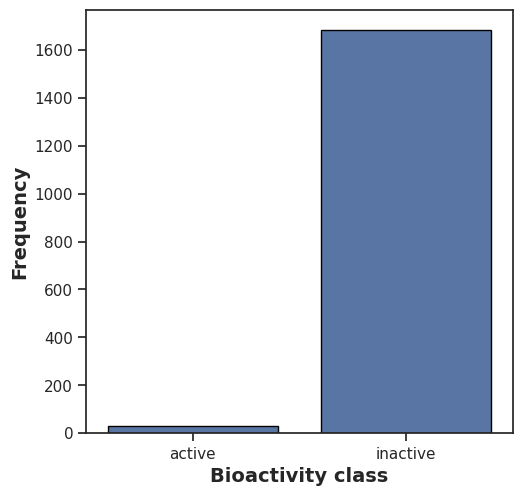

In [66]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x='class', data=df_2class, edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('plot_bioactivity_class.pdf')

### **Scatter plot of MW versus LogP**

It can be seen that the 2 bioactivity classes are spanning similar chemical spaces as evident by the scatter plot of MW vs LogP.

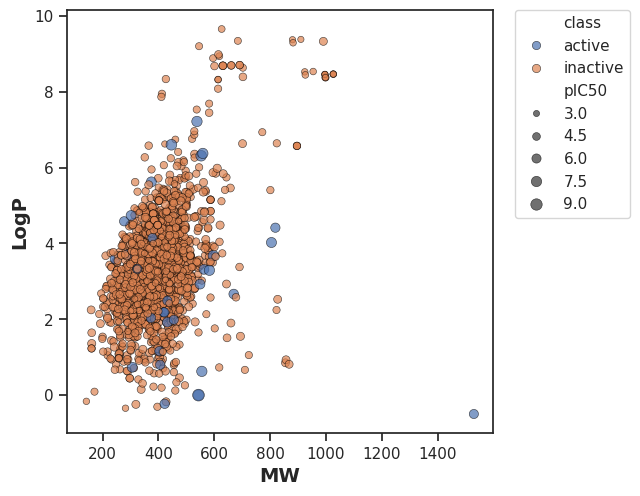

In [67]:
plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x='MW', y='LogP', data=df_2class, hue='class', size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.savefig('plot_MW_vs_LogP.pdf')

### **Box plots**

#### **pIC50 value**

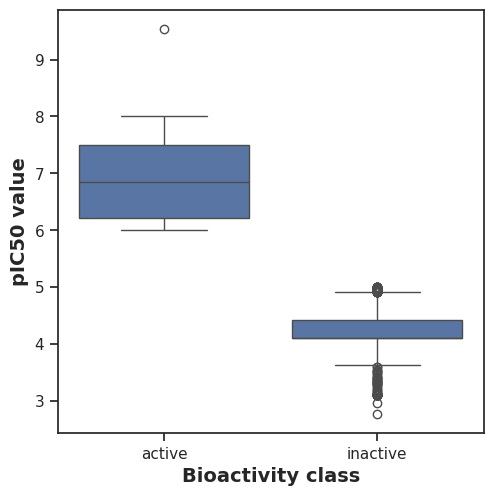

In [68]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'pIC50', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')

plt.savefig('plot_ic50.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [69]:
def mannwhitney(descriptor, verbose=False):
  # https://machinelearningmastery.com/nonparametric-statistical-significance-tests-in-python/
  from numpy.random import seed
  from numpy.random import randn
  from scipy.stats import mannwhitneyu

# seed the random number generator
  seed(1)

# actives and inactives
  selection = [descriptor, 'class']
  df = df_2class[selection]
  active = df[df['class'] == 'active']
  active = active[descriptor]

  selection = [descriptor, 'class']
  df = df_2class[selection]
  inactive = df[df['class'] == 'inactive']
  inactive = inactive[descriptor]

# compare samples
  stat, p = mannwhitneyu(active, inactive)
  #print('Statistics=%.3f, p=%.3f' % (stat, p))

# interpret
  alpha = 0.05
  if p > alpha:
    interpretation = 'Same distribution (fail to reject H0)'
  else:
    interpretation = 'Different distribution (reject H0)'

  results = pd.DataFrame({'Descriptor':descriptor,
                          'Statistics':stat,
                          'p':p,
                          'alpha':alpha,
                          'Interpretation':interpretation}, index=[0])
  filename = 'mannwhitneyu_' + descriptor + '.csv'
  results.to_csv(filename)

  return results

In [70]:
mannwhitney('pIC50')

,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,53856.0,1.283164e-27,0.05,Different distribution (reject H0)


#### **MW**

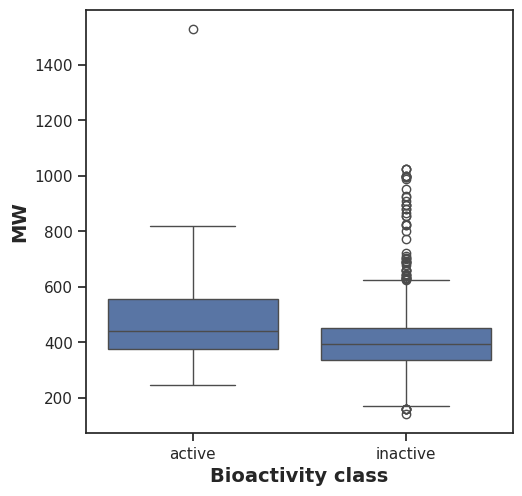

In [71]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'MW', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

plt.savefig('plot_MW.pdf')

In [72]:
mannwhitney('MW')

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,35324.5,0.002483,0.05,Different distribution (reject H0)


#### **LogP**

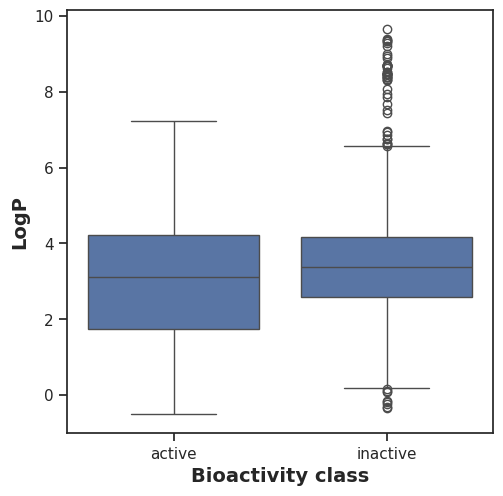

In [73]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'LogP', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')

plt.savefig('plot_LogP.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [74]:
mannwhitney('LogP')

,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,23004.0,0.15742,0.05,Same distribution (fail to reject H0)


#### **NumHDonors**

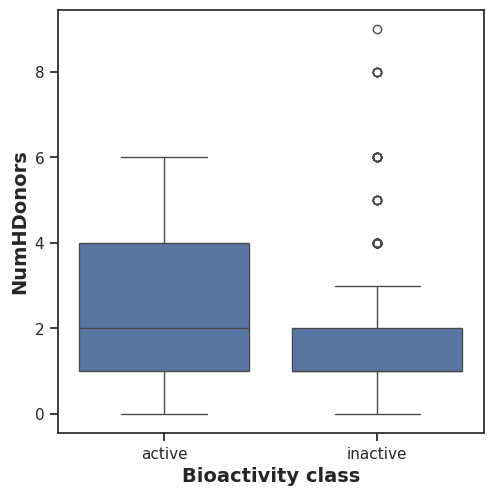

In [75]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'NumHDonors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHDonors.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [76]:
mannwhitney('NumHDonors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,32855.0,0.022844,0.05,Different distribution (reject H0)


#### **NumHAcceptors**

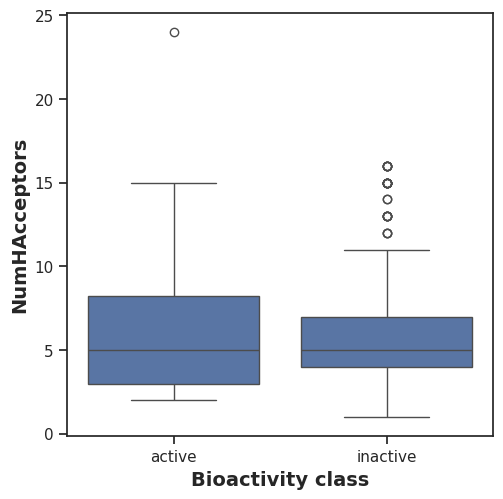

In [77]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'NumHAcceptors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHAcceptors.pdf')

In [78]:
mannwhitney('NumHAcceptors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,26940.5,0.996494,0.05,Same distribution (fail to reject H0)


#### **Interpretation of Statistical Results**

##### **Box Plots**

###### **pIC50 values**

Taking a look at pIC50 values, the **actives** and **inactives** displayed ***statistically significant difference***, which is to be expected since threshold values (``IC50 < 1,000 nM = Actives while IC50 > 10,000 nM = Inactives``, corresponding to ``pIC50 > 6 = Actives and pIC50 < 5 = Inactives``) were used to define actives and inactives.

###### **Lipinski's descriptors**

All of the 4 Lipinski's descriptors exhibited ***statistically significant difference*** between the **actives** and **inactives**.

## **Zip files**

In [79]:
! zip -r results.zip . -i *.csv *.pdf

  adding: acetylcholinesterase_03_bioactivity_data_curated.csv (deflated 82%)
  adding: plot_LogP.pdf (deflated 37%)
  adding: H9c2_03_bioactivity_data_curated.csv (deflated 78%)
  adding: plot_NumHAcceptors.pdf (deflated 37%)
  adding: plot_MW_vs_LogP.pdf (deflated 3%)
  adding: mannwhitneyu_NumHAcceptors.csv (deflated 11%)
  adding: H92C_02_pIC50.csv (deflated 74%)
  adding: plot_ic50.pdf (deflated 33%)
  adding: plot_NumHDonors.pdf (deflated 37%)
  adding: plot_bioactivity_class.pdf (deflated 37%)
  adding: mannwhitneyu_MW.csv (deflated 9%)
  adding: mannwhitneyu_pIC50.csv (deflated 10%)
  adding: H9C2_pIC50.csv (deflated 74%)
  adding: mannwhitneyu_LogP.csv (deflated 10%)
  adding: mannwhitneyu_NumHDonors.csv (deflated 10%)
  adding: plot_MW.pdf (deflated 37%)
